In [126]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, root_mean_squared_error, mean_squared_error
from sklearn.impute import SimpleImputer
import pandas as pd
import matplotlib.pyplot as plt
from joblib import dump
import gdown

In [127]:
url='https://drive.google.com/uc?id=1hzmxNBrY7-9mv5EpqAvhVUiJahfrcYUN&export=download'

output='../data/epi_r.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1hzmxNBrY7-9mv5EpqAvhVUiJahfrcYUN&export=download
To: /home/mirshod/Desktop/DSB12_Food_nutrition.ID_886525-Vireon.83e608aa_1bae_4768-1/src/data/epi_r.csv
100%|██████████| 55.3M/55.3M [00:06<00:00, 8.65MB/s]


'../data/epi_r.csv'

In [128]:
df=pd.read_csv('../data/epi_r.csv')
df.head()

,title,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,...,yellow squash,yogurt,yonkers,yuca,zucchini,cookbooks,leftovers,snack,snack week,turkey
0,"Lentil, Apple, and Turkey Wrap",2.500,426.0,30.0,7.0,559.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Boudin Blanc Terrine with Red Onion Confit,4.375,403.0,18.0,23.0,1439.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Potato and Fennel Soup Hodge,3.750,165.0,6.0,7.0,165.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mahi-Mahi in Tomato Olive Sauce,5.000,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Spinach Noodle Casserole,3.125,547.0,20.0,32.0,452.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [129]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20052 entries, 0 to 20051
Columns: 680 entries, title to turkey
dtypes: float64(679), object(1)
memory usage: 104.0+ MB


In [130]:
df.describe()

,rating,calories,protein,fat,sodium,#cakeweek,#wasteless,22-minute meals,3-ingredient recipes,30 days of groceries,...,yellow squash,yogurt,yonkers,yuca,zucchini,cookbooks,leftovers,snack,snack week,turkey
count,20052.000000,1.593500e+04,15890.000000,1.586900e+04,1.593300e+04,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000,...,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000,20052.000000
mean,3.714467,6.322958e+03,100.160793,3.468775e+02,6.225975e+03,0.000299,0.000050,0.000848,0.001346,0.000349,...,0.001247,0.026332,0.000050,0.000299,0.014861,0.000150,0.000349,0.001396,0.000948,0.022741
std,1.340829,3.590460e+05,3840.318527,2.045611e+04,3.333182e+05,0.017296,0.007062,0.029105,0.036671,0.018681,...,0.035288,0.160123,0.007062,0.017296,0.121001,0.012231,0.018681,0.037343,0.030768,0.149080
min,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.750000,1.980000e+02,3.000000,7.000000e+00,8.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.375000,3.310000e+02,8.000000,1.700000e+01,2.940000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,4.375000,5.860000e+02,27.000000,3.300000e+01,7.110000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,3.011122e+07,236489.000000,1.722763e+06,2.767511e+07,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [177]:
ingredients = [
    'milk', 'jam', 'almond', 'amaretto', 'anchovy', 'anise', 'apple', 'apple juice', 'apricot',
    'artichoke', 'arugula', 'asian pear', 'asparagus', 'avocado', 'bacon', 'banana',
    'barley', 'basil', 'bass', 'bean', 'beef', 'beef rib', 'beef shank', 'beef tenderloin',
    'beer', 'beet', 'bell pepper', 'berry', 'biscuit', 'bitters', 'blackberry', 'blue cheese',
    'blueberry', 'bok choy', 'bran', 'brandy', 'bread', 'breadcrumbs', 'brie', 'brisket',
    'broccoli', 'broccoli rabe', 'brown rice', 'brownie', 'brussel sprout', 'buffalo',
    'bulgur', 'burrito', 'butter', 'buttermilk', 'butternut squash', 'butterscotch/caramel',
    'cabbage', 'cake', 'candy', 'cantaloupe', 'capers', 'caraway', 'cardamom', 'carrot',
    'cashew', 'cauliflower', 'caviar', 'celery', 'chambord', 'champagne', 'chard',
    'cheddar', 'cheese', 'cherry', 'chestnut', 'chicken', 'chickpea', 'chile',
    'chile pepper', 'chili', 'chive', 'chocolate', 'cilantro', 'cinnamon', 'citrus',
    'clam', 'clove', 'coconut', 'cod', 'coffee', 'collard greens', 'cookie', 'cookies',
    'coriander', 'corn', 'cornmeal', 'cottage cheese', 'couscous', 'crab', 'cranberry',
    'cranberry sauce', 'cream cheese', 'créme de cacao', 'crêpe', 'cucumber', 'cumin',
    'cupcake', 'currant', 'curry', 'custard', 'dairy', 'date', 'dill', 'duck', 'egg',
    'egg nog', 'eggplant', 'endive', 'escarole', 'fennel', 'feta', 'fig', 'fish',
    'flat bread', 'fontina', 'fruit', 'fruit juice', 'garlic', 'ginger', 'goat cheese',
    'goose', 'gouda', 'grains', 'granola', 'grape', 'grapefruit', 'green bean',
    'green onion/scallion', 'ground beef', 'ground lamb', 'guava', 'halibut', 'ham',
    'hamburger', 'hazelnut', 'herb', 'hominy/cornmeal/masa', 'honey', 'honeydew',
    'horseradish', 'hummus', 'ice cream', 'jam or jelly', 'jalapeño', 'jícama', 'kale',
    'kiwi', 'kumquat', 'lamb', 'lamb chop', 'lamb shank', 'lasagna', 'leafy green',
    'leek', 'legume', 'lemon', 'lemon juice', 'lemongrass', 'lentil', 'lettuce',
    'lima bean', 'lime', 'lime juice', 'lingonberry', 'lobster', 'macadamia nut',
    'macaroni and cheese', 'mango', 'maple syrup', 'marinade', 'marsala', 'marshmallow',
    'mascarpone', 'mayonnaise', 'meat', 'meatball', 'meatloaf', 'melon', 'milk/cream',
    'mint', 'molasses', 'monterey jack', 'mozzarella', 'muffin', 'mushroom', 'mussel',
    'mustard', 'mustard greens', 'nectarine', 'noodle', 'nut', 'nutmeg', 'oat',
    'oatmeal', 'octopus', 'okra', 'olive', 'omelet', 'onion', 'orange', 'orange juice',
    'oregano', 'orzo', 'oyster', 'papaya', 'paprika', 'parmesan', 'parsley', 'parsnip',
    'pea', 'peach', 'peanut', 'peanut butter', 'pear', 'pecan', 'pepper', 'persimmon',
    'pine nut', 'pineapple', 'pistachio', 'plantain', 'plum', 'poblano', 'pomegranate',
    'pomegranate juice', 'poppy', 'pork', 'pork chop', 'pork rib', 'pork tenderloin',
    'potato', 'poultry', 'poultry sausage', 'prosciutto', 'prune', 'pumpkin', 'quail',
    'quiche', 'quince', 'quinoa', 'rabbit', 'radicchio', 'radish', 'raisin', 'raspberry',
    'red wine', 'rhubarb', 'rice', 'ricotta', 'rosemary', 'rosé', 'rum', 'rutabaga',
    'rye', 'saffron', 'sage', 'sake', 'salmon', 'salsa', 'sardine', 'sausage', 'scallop',
    'seafood', 'seed', 'semolina', 'sesame', 'sesame oil', 'shallot', 'shellfish',
    'sherry', 'shrimp', 'snapper', 'sorbet', 'sour cream', 'spinach', 'spice', 'squash',
    'squid', 'steak', 'strawberry', 'stuffing/dressing', 'sugar snap pea', 'sweet potato/yam',
    'swiss cheese', 'swordfish', 'tamarind', 'tangerine', 'tapioca', 'tarragon', 'tea',
    'thyme', 'tilapia', 'tofu', 'tomatillo', 'tomato', 'tortillas', 'trout', 'tuna',
    'turnip', 'turkey', 'vanilla', 'veal', 'vegetable', 'vinegar', 'walnut', 'wasabi',
    'watercress', 'watermelon', 'wheat/gluten-free', 'white wine', 'wild rice', 'wine',
    'yogurt', 'zucchini'
]


ingredients_df = df[[col for col in df.columns if col.lower() in ingredients]]
ingredients_df=pd.concat([df['title'], ingredients_df], axis=1)
# ingredients_df.drop(columns=['Unnamed: 0'])
ingredients_df.to_csv('../data/ingredients_df.csv')

In [178]:
ingredients_df.head()

,title,almond,amaretto,anchovy,anise,apple,apple juice,apricot,artichoke,arugula,...,wasabi,watercress,watermelon,wheat/gluten-free,white wine,wild rice,wine,yogurt,zucchini,turkey
0,"Lentil, Apple, and Turkey Wrap",0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Boudin Blanc Terrine with Red Onion Confit,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Potato and Fennel Soup Hodge,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Mahi-Mahi in Tomato Olive Sauce,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Spinach Noodle Casserole,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [131]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: title
title
Pastry Dough                                                 28
Chicken Stock                                                26
Turkey Giblet Stock                                          20
Turkey Stock                                                 15
Simple Syrup                                                 13
                                                             ..
Beef Tenderloin with Garlic and Brandy                        1
Banana-Chocolate Chip Cake With Peanut Butter Frosting        1
Spicy Noodle Soup                                             1
Yams Braised with Cream, Rosemary and Nutmeg                  1
Ham Persillade with Mustard Potato Salad and Mashed Peas      1
Name: count, Length: 17736, dtype: int64




In [132]:
numerical_cols = df.select_dtypes(include=['float64']).columns
numerical_cols

Index(['rating', 'calories', 'protein', 'fat', 'sodium', '#cakeweek',
       '#wasteless', '22-minute meals', '3-ingredient recipes',
       '30 days of groceries',
       ...
       'yellow squash', 'yogurt', 'yonkers', 'yuca', 'zucchini', 'cookbooks',
       'leftovers', 'snack', 'snack week', 'turkey'],
      dtype='object', length=679)

In [133]:
impute=SimpleImputer(strategy="most_frequent").fit(df[numerical_cols])
df[numerical_cols]=impute.transform(df[numerical_cols])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20052 entries, 0 to 20051
Columns: 680 entries, title to turkey
dtypes: float64(679), object(1)
memory usage: 104.0+ MB


In [134]:
y=df['rating']
X=df[['sodium','protein','fat','calories']]

In [135]:
df.drop(columns=[ 'rating', 'sodium', 'protein', 'fat', 'calories'], inplace=True)

In [136]:
ingredient_cols = df.columns[ df.dtypes == "float64" ]

df["ingredients"] = df[ingredient_cols].apply(
    lambda row: [col for col in ingredient_cols if row[col] == 1],
    axis=1
)

In [137]:
def make_slug(title):
    return (
        title.lower()
        .replace(" ", "-")
        .replace(",", "")
        .replace("'", "")
    )

ids = pd.Series(df.index.astype(str), index=df.index)

def build_url(row):
    title = row.get('title', '')
    return f"https://www.epicurious.com/recipes/food/views/{make_slug(title)}-{ids.loc[row.name]}"

df["url"] = df.apply(build_url, axis=1)


In [138]:
pd.concat([df[['title', 'url', 'ingredients']], y], axis=1).to_csv('../data/recipes_urls.csv', index=False)

In [163]:
import requests
API_KEY = "qchHPy2OFWPbSiZbehlbhh2DO639ubjQJBowezNp"

def search_ingredient(ingredient):
    url = f"https://api.nal.usda.gov/fdc/v1/foods/search"
    params = {
        "query": ingredient,
        "api_key": API_KEY,
        "pageSize": 1,
        "dataType": ["Survey (FNDDS)", "Foundation"]
    }
    response = requests.get(url, params=params)
    if response.status_code == 200:
        foods = response.json().get("foods", [])
        if foods:
            return foods[0]["fdcId"]
    return None

In [162]:
DAILY_VALUES = {
    "Total Fat": 78,
    "Saturated Fat": 20,
    "Cholesterol": 300,
    "Total Carbohydrate": 275,
    "Dietary Fiber": 28,
    "Total Sugars": 50,
    "Sodium": 2300,
    "Protein": 50,

    "Vitamin A": 900, 
    "Vitamin C": 90,
    "Calcium": 1300,
    "Iron": 18,
    "Vitamin D": 20, 
    "Vitamin E": 15,
    "Vitamin K": 120, 
    "Thiamin": 1.2,
    "Riboflavin": 1.3,
    "Niacin": 16,
    "Vitamin B6": 1.7,
    "Folate": 400,
    "Vitamin B12": 2.4,
    "Biotin": 30,
    "Pantothenic acid": 5,
    "Phosphorus": 1250,
    "Iodine": 150,
    "Magnesium": 420,
    "Zinc": 11,
    "Selenium": 55,
    "Copper": 0.9,
    "Manganese": 2.3,
    "Chromium": 35,
    "Molybdenum": 45,
    "Chloride": 2300,
    "Potassium": 4700,
    "Choline": 550
}

In [164]:
def get_nutrition(fdc_id):
    url = f"https://api.nal.usda.gov/fdc/v1/food/{fdc_id}?api_key={API_KEY}"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()
    return None


# DO NOT RUN BELOW CELL, IT TAKES 20 MINUTES

In [169]:
import time
ingredients = list(ingredients_df.columns)
results = []

for ingredient in ingredients:
    fdc_id = search_ingredient(ingredient)
    if fdc_id:
        data = get_nutrition(fdc_id)
        nutrient_data = {"ingredient": ingredient}

        for nutrient in data.get("foodNutrients", []):
            name = nutrient["nutrient"]["name"]
            amount = nutrient.get("amount")
            unit = nutrient["nutrient"]["unitName"]

            if name in DAILY_VALUES and amount:
                daily_value = DAILY_VALUES[name]

                if unit.upper() in ["UG", "MCG"]:
                    amount = amount / 1000
                if unit.upper() == "MG":
                    amount = amount / 1000
                nutrient_data[name] = (amount / daily_value) * 100


                pct_dv = (amount / daily_value) * 100
                nutrient_data[name] = round(pct_dv, 2)
                
        results.append(nutrient_data)
        time.sleep(1)

df_nutrition = pd.DataFrame(results)


In [179]:
df_nutrition=pd.concat([df['title'], df_nutrition], axis=1)
if 'Unnamed: 0' in df_nutrition.columns:
    df_nutrition.drop(columns=['Unnamed: 0'])
df_nutrition.to_csv("../data/nutrition_facts_pct.csv")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb


from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV


import warnings
warnings.filterwarnings('ignore')


class TreeRegressionModels:

    def __init__(self, model_name='decisiontree', X=X, y=y, sampling='no', use_pca=False, best_param={}):


        """
        This class intended to reduce the size code blocks, and
        to automate the process of modelling!

        This class the result of 2 days of headache!
        __init__ function initilizes model and merges oversampling, undersampling classes, PCA and model itself!
        """

        self.X, self.y = X, y
        self.model_name = model_name.lower()
        # self.grid=None

        self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
            self.X, self.y,
            test_size=0.2,
            random_state=42
        )

        models = ['xgboost', 'randomforest', 'decisiontree']
        if self.model_name not in models:
            raise ValueError("Invalid model name!")

        print('='*10, f'{self.model_name.capitalize()} Model Initialization!', '='*10)

        if self.model_name == 'decisiontree':
            self.model = DecisionTreeRegressor()
        elif self.model_name == 'randomforest':
            self.model = RandomForestRegressor()
        elif self.model_name == 'xgboost':
            self.model = xgb.XGBRFRegressor()


        # If the target appears to be a continuous regression variable,
        # imblearn samplers like SMOTE / RandomUnderSampler are not appropriate.
        # Detect continuous target and fall back to no sampling with a warning.
        try:
            y_series = pd.Series(self.y)
            is_continuous = pd.api.types.is_float_dtype(y_series) and y_series.nunique() > 10
        except Exception:
            is_continuous = False

        if is_continuous and sampling in ['over', 'under']:
            print("Warning: target appears continuous (regression). Skipping over/under sampling and using no sampling.")
            sampling = 'no'

        if sampling == 'over':
            if use_pca:
                self.pipe = Pipeline([
                    ('smote', SMOTE(sampling_strategy=1.0)),
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])

            else:
                self.pipe = Pipeline([
                    ('smote', SMOTE(sampling_strategy=1.0)),
                    ('model', self.model)
                ])

        elif sampling == 'under':
            if use_pca:
                self.pipe = Pipeline([
                    ('RandomUnderSampler', RandomUnderSampler(sampling_strategy=1.0)),
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])
            else:
                self.pipe = Pipeline([
                    ('RandomUnderSampler', RandomUnderSampler(sampling_strategy=1.0)),
                    ('model', self.model)
                ])

        elif sampling == 'no':
            if use_pca:
                self.pipe = Pipeline([
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])

            else:
                self.pipe = Pipeline([
                    ('model', self.model)
                ])


        if best_param:
            if isinstance(best_param, tuple):
                best_param=best_param[0]
            self.pipe.set_params(**best_param)

        print('======== PIPELINE FOR SPECIFIED MODEL: ========')
        print(self.pipe)

    def train_model_and_evalute(self, show=True):

        """
        Trains the model and evaluates its performance using test.
        Returns a dictionary containing accuracy, precision, recall, and F1 score.
        """

        self.pipe.fit(self.train_x, self.train_y)
        prediction = self.pipe.predict(self.test_x)

        self.r2=r2_score(self.test_y, prediction)
        self.rmse=root_mean_squared_error(self.test_y, prediction)
        self.mse=mean_squared_error(self.test_y, prediction)
        self.msa=mean_absolute_error(self.test_y, prediction)

        if show:
          print(f'{self.model_name.capitalize()} Results:')
          print("R2 Error:", self.r2)
          print("Root Mean Squared Error:", self.rmse)
          print("Mean Squared Error:", self.mse)
          print("Mean Absolute Error:", self.msa)

        return {
            'root_mean_squared_error' : self.rmse,
            'r2_score' : self.r2,
            'mean_squared_error' : self.mse,
            'mean_absolute_error' : self.msa
        }


    def hyperparameter_tuning(self):

        print('='*10, f'{self.model_name.capitalize()} Hyperparameter Tuning!', '='*10)

        param_grid={}

        if self.model_name == 'decisiontree':
            param_grid = {
                'model__max_depth': range(1, 50), # if model is deeper, it will be prone to overfit, common problem in tree-based models
                'model__min_samples_split': [2, 10], # it is mainly for generalizing the model performance
                'model__min_samples_leaf': [1, 4], # mostly useful to avoid specific predictions, it stands for minimum number of sample required to be in leaf node
                'model__ccp_alpha': [0.0, 0.001],
                'model__splitter': ['best']
            } # all above parameters assigned to control overfitting, because it is common for Complex Models

        elif self.model_name == 'randomforest':
            param_grid = {
                'model__n_estimators': [100, 200], # defines the number of decision trees in the forest, higher number of estimators increases the complexity of model
                'model__max_depth': [None, 20, 40],
                'model__min_samples_split': [2, 5],
                'model__min_samples_leaf': [1, 2],
                'model__max_features': ['sqrt', 'log2'] # this parameter is used for reducing correlation and increasing generalization
            }

        elif self.model_name == 'xgboost':
            param_grid = {
                'model__n_estimators': [200, 400],
                'model__learning_rate': [0.05, 0.1], # the smaller learning rate, the more generalized model, but it requires more trees
                'model__max_depth': [4, 6, 8],
                'model__min_child_weight': [1, 3], # stands for minimum sum of instance weights in a child node
                'model__subsample': [0.8, 1.0], # by specifying this parameter, adding randomness and reducing overfitting to model is aimed
                'model__colsample_bytree': [0.8, 1.0] # intention the same as subsamples, applied to features, but subsamples is applies for training data
            }

        # cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        self.grid=GridSearchCV(
            estimator=self.pipe,
            param_grid=param_grid,
            cv=5,
            n_jobs=1,
            scoring='r2'
        )

        self.grid.fit(self.train_x, self.train_y)
        print('Best Parameters :', self.grid.best_params_)
        self.y_pred= self.grid.best_estimator_.predict(self.test_x)
        self.r2=r2_score(self.test_y, self.y_pred)
        self.rmse=root_mean_squared_error(self.test_y, self.y_pred)
        self.mse=mean_squared_error(self.test_y, self.y_pred)
        self.msa=mean_absolute_error(self.test_y, self.y_pred)

        print(f'{self.model_name.capitalize()} Results:')
        print("R2 Error:", self.r2)
        print("Root Mean Squared Error:", self.rmse)
        print("Mean Squared Error:", self.mse)
        print("Mean Absolute Error:", self.msa)

        return self.grid.best_params_

    def plot_predicted_actual(self):
        plt.scatter(self.test_y, self.y_pred)
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{self.model_name.capitalize()} Actual vs Predicted")
        plt.show()

    def plot_residuals(self):
        residuals=self.test_y-self.y_pred
        plt.scatter(self.y_pred, residuals)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.xlabel("Predicted")
        plt.ylabel("Residuals")
        plt.title(f"{self.model_name.capitalize()} Residual Plot")
        plt.show()


In [140]:
dtree_model=TreeRegressionModels(model_name='decisiontree', X=X, y=y, sampling='no', use_pca=False)
dtree_scores=dtree_model.train_model_and_evalute()

========== Decisiontree Model Initialization! ==========
======== PIPELINE FOR SPECIFIED MODEL: ========
Pipeline(steps=[('model', DecisionTreeRegressor())])
Decisiontree Results:
R2 Error: -0.4638290481065104
Root Mean Squared Error: 1.5784057187132599
Mean Squared Error: 2.4913646128667226
Mean Absolute Error: 0.9857487650614831


In [141]:
dtree_model.hyperparameter_tuning()

========== Decisiontree Hyperparameter Tuning! ==========
Best Parameters : {'model__ccp_alpha': 0.0, 'model__max_depth': 4, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__splitter': 'best'}
Decisiontree Results:
R2 Error: 0.038343466397183334
Root Mean Squared Error: 1.279332575823141
Mean Squared Error: 1.6366918395622732
Mean Absolute Error: 0.88876575231139


{'model__ccp_alpha': 0.0,
 'model__max_depth': 4,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 10,
 'model__splitter': 'best'}

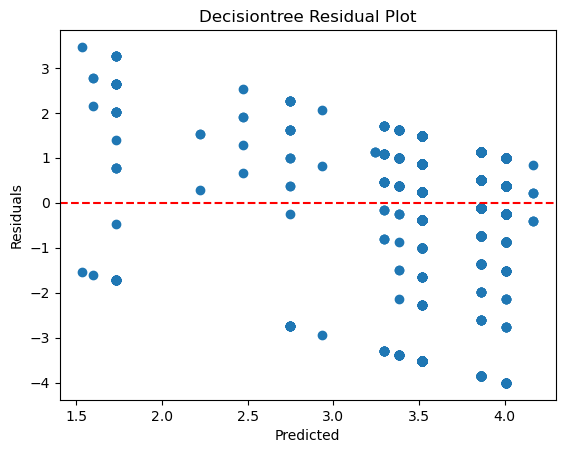

In [142]:
dtree_model.plot_residuals()

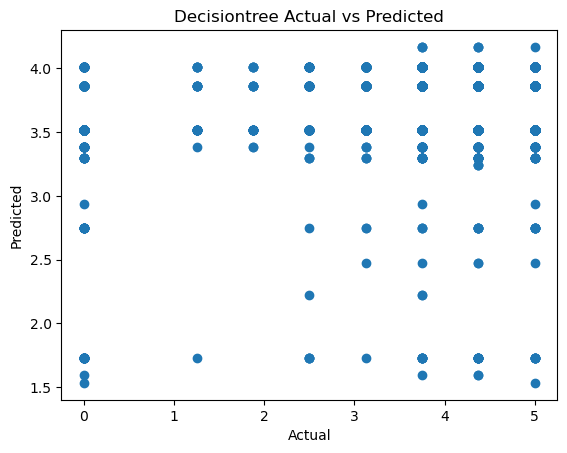

In [143]:
dtree_model.plot_predicted_actual()

In [144]:
rdm_forest=TreeRegressionModels(model_name='randomforest', X=X, y=y, sampling='no', use_pca=False)
rdm_scores=rdm_forest.train_model_and_evalute()

========== Randomforest Model Initialization! ==========
======== PIPELINE FOR SPECIFIED MODEL: ========
Pipeline(steps=[('model', RandomForestRegressor())])
Randomforest Results:
R2 Error: 0.057200932637126556
Root Mean Squared Error: 1.2667270286243373
Mean Squared Error: 1.6045973650474423
Mean Absolute Error: 0.8639823505383423


In [145]:
best_params=rdm_forest.hyperparameter_tuning()

========== Randomforest Hyperparameter Tuning! ==========
Best Parameters : {'model__max_depth': 20, 'model__max_features': 'log2', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Randomforest Results:
R2 Error: 0.08141858431251181
Root Mean Squared Error: 1.2503519984914493
Mean Squared Error: 1.5633801201315611
Mean Absolute Error: 0.8530448503047228


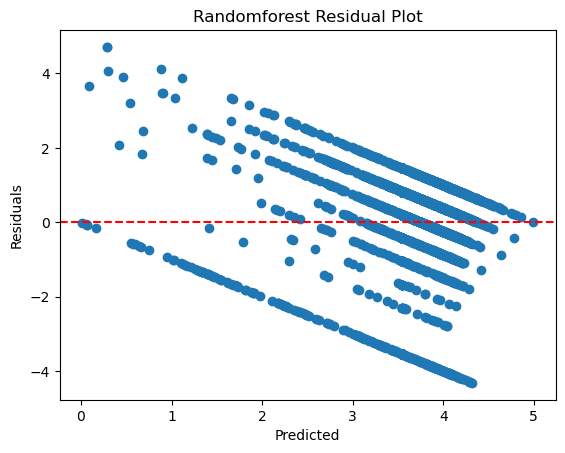

In [146]:
rdm_forest.plot_residuals()

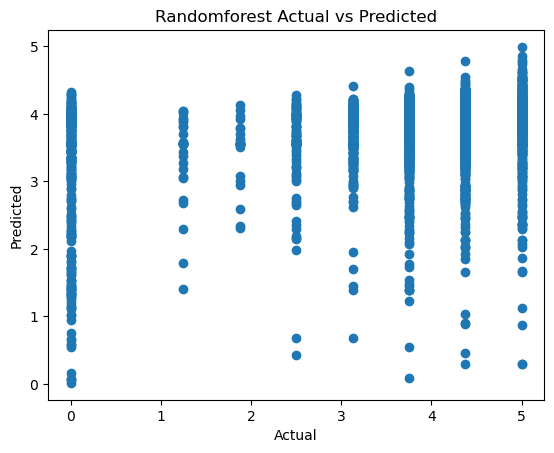

In [147]:
rdm_forest.plot_predicted_actual()

In [148]:
joblib.dump(rdm_forest, 'model.pkl')

['model.pkl']

In [149]:
xgboost_model=TreeRegressionModels(model_name='xgboost', X=X, y=y, sampling='no', use_pca=False)
xgb_scores=xgboost_model.train_model_and_evalute()

========== Xgboost Model Initialization! ==========
======== PIPELINE FOR SPECIFIED MODEL: ========
Pipeline(steps=[('model',
                 XGBRFRegressor(base_score=None, booster=None, callbacks=None,
                                colsample_bylevel=None, colsample_bytree=None,
                                device=None, early_stopping_rounds=None,
                                enable_categorical=False, eval_metric=None,
                                feature_types=None, feature_weights=None,
                                gamma=None, grow_policy=None,
                                importance_type=None,
                                interaction_constraints=None, max_bin=None,
                                max_cat_threshold=None, max_cat_to_onehot=None,
                                max_delta_step=None, max_depth=None,
                                max_leaves=None, min_child_weight=None,
                                missing=nan, monotone_constraints=None,
        

In [150]:
best_params=xgboost_model.hyperparameter_tuning()

========== Xgboost Hyperparameter Tuning! ==========
Best Parameters : {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__min_child_weight': 1, 'model__n_estimators': 400, 'model__subsample': 0.8}
Xgboost Results:
R2 Error: 0.012403802091713323
Root Mean Squared Error: 1.2964720840701498
Mean Squared Error: 1.6808398647731977
Mean Absolute Error: 0.8714224229991897


In [151]:
rating_map={1: 'bad', 2: 'bad', 3: 'so-so', 4: 'so-so', 5: 'great'}

y_class=y.apply(lambda rating: rating_map.get(round(rating), 'bad'))
y_class

0          bad
1        so-so
2        so-so
3        great
4        so-so
         ...  
20047    so-so
20048    so-so
20049    so-so
20050    so-so
20051    so-so
Name: rating, Length: 20052, dtype: object

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, classification_report, precision_score, recall_score, auc, roc_curve,
    precision_recall_curve, roc_auc_score, confusion_matrix, f1_score
    )

import os
os.environ["JOBLIB_MULTIPROCESSING"] = "0"
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbn


class Classification_Models:

    def __init__(self, model_name='decisiontree', X=X, y=y_class, sampling='no', use_pca=False, best_param={}):


        """
        This class intended to reduce the size code blocks, and
        to automate the process of modelling!

        __init__ function initilizes model and merges oversampling, undersampling classes, PCA and model itself!
        """

        self.X, self.y = X, y
        self.model_name = model_name.lower()
        # self.grid=None

        self.train_x, self.test_x, self.train_y, self.test_y = train_test_split(
            self.X, self.y,
            test_size=0.2,
            stratify=self.y,
            random_state=42
        )

        models = ['decisiontree', 'randomforest', 'xgboost', 'lightgbm']
        if self.model_name not in models:
            raise ValueError("Invalid model name!")

        print('='*10, f'{self.model_name.capitalize()} Model Initialization!', '='*10)

        if self.model_name == 'decisiontree':
            self.model = DecisionTreeClassifier(class_weight='balanced')
        elif self.model_name == 'randomforest':
            self.model = RandomForestClassifier(class_weight='balanced')
        elif self.model_name == 'xgboost':
            self.model = xgb.XGBClassifier()
        elif self.model_name == 'lightgbm':
            self.model = LGBMClassifier()


        if sampling == 'over':
            if use_pca:
                self.pipe = Pipeline([
                    ('smote', SMOTE(sampling_strategy=1.0)),
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])

            else:
                self.pipe = Pipeline([
                    ('smote', SMOTE(sampling_strategy=1.0)),
                    ('model', self.model)
                ])

        elif sampling == 'under':
            if use_pca:
                self.pipe = Pipeline([
                    ('RandomUnderSampler', RandomUnderSampler(sampling_strategy=1.0)),
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])
            else:
                self.pipe = Pipeline([
                    ('RandomUnderSampler', RandomUnderSampler(sampling_strategy=1.0)),
                    ('model', self.model)
                ])

        elif sampling == 'no':
            if use_pca:
                self.pipe = Pipeline([
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])

            else:
                self.pipe = Pipeline([
                    ('pca', PCA(n_components=0.95)),
                    ('model', self.model)
                ])


        if best_param:
            if isinstance(best_param, tuple):
                best_param=best_param[0]
            self.pipe.set_params(**best_param)

        print('======== PIPELINE FOR SPECIFIED MODEL: ========')
        print(self.pipe)

    def train_model_and_evalute(self, show=True):

        """
        Trains the model and evaluates its performance using test.
        Returns a dictionary containing accuracy, precision, recall, and F1 score.
        """

        self.pipe.fit(self.train_x, self.train_y)
        prediction = self.pipe.predict(self.test_x)

        acc=accuracy_score(self.test_y, prediction)
        pre_sc=precision_score(self.test_y, prediction, average='weighted')
        rec_sc=recall_score(self.test_y, prediction, average='weighted')
        f1=f1_score(self.test_y, prediction, average='weighted')

        if show:
          print(f'{self.model_name.capitalize()} Results:')
          print("Accuracy:", acc)
          print("Precision:", pre_sc)
          print("Recall:", rec_sc)
          print("F1:", f1)

          print("\n===== Classification Report =====\n")
          print(classification_report(self.test_y, prediction))

        return {
            'accuracy' : acc,
            'precision' : pre_sc,
            'recall' : rec_sc,
            'f1' : f1
        }


    def hyperparameter_tuning(self):

        print('='*10, f'{self.model_name.capitalize()} Hyperparameter Tuning!', '='*10)

        param_grid={}

        if self.model_name == 'decisiontree':
            param_grid = {
                  'model__criterion': ['gini'],
                  'model__splitter': ['best'],
                  'model__max_depth': [10, 20, 30],
                  'model__min_samples_split': [2, 10],
                  'model__min_samples_leaf': [1, 4],
                  'model__class_weight': ['balanced'], # dataset is potentially unbalanced so, it is used
                  'model__ccp_alpha': [0.0, 0.001]
              } # left parameters the same as used in regression

        elif self.model_name == 'randomforest':
            param_grid = {
                  'model__n_estimators': [100],          # Fix tree count to reduce training time
                  'model__max_depth': [10, 20],          # Remove unlimited depth to prevent very deep trees
                  'model__max_features': ['sqrt'],       # Use default, best-performing option
                  'model__min_samples_split': [2],       # Default split behavior
                  'model__min_samples_leaf': [1, 4]
                }

        elif self.model_name == 'xgboost':
            param_grid = {
                    "model__max_depth": [3, 5, 7],
                    "model__learning_rate": [0.05, 0.1, 0.2],
                    "model__n_estimators": [100, 200],
                    "model__subsample": [0.7, 1.0],
                    "model__colsample_bytree": [0.7, 1.0],
                }
        elif self.model_name == 'lightgbm':
            param_grid = {
                      "model__boosting_type": ["dart"],  # Dropouts meet Multiple Additive Regression Trees (DART) to reduce overfitting by randomly dropping trees during training
                      "model__drop_rate": [0.05, 0.1],   # higher values increase regularization and reduce overfitting
                      "model__skip_drop": [0.5, 0.7],    # higher values preserve model stability while still applying regularization
                      'model__force_col_wise': [True]
                  }


        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

        self.grid=GridSearchCV(
            estimator=self.pipe,
            param_grid=param_grid,
            cv=cv,
            n_jobs=1,
            scoring='f1_weighted'
        )

        self.grid.fit(self.train_x, self.train_y)
        print('Best Parameters :', self.grid.best_params_)
        self.y_pred= self.grid.best_estimator_.predict(self.test_x)
        acc=accuracy_score(self.test_y, self.y_pred)
        pre_sc=precision_score(self.test_y, self.y_pred, average='weighted')
        rec_sc=recall_score(self.test_y, self.y_pred, average='weighted')
        f1=f1_score(self.test_y, self.y_pred, average='weighted')

        print("Accuracy:", acc)
        print("Precision:", pre_sc)
        print("Recall:", rec_sc)
        print("F1:", f1)

        return self.grid.best_params_


    def roc_and_auc(self):
        from sklearn.preprocessing import label_binarize

        classes = np.unique(self.test_y)
        # Binary case
        if len(classes) == 2:
            if self.model_name == 'linearsv':
                prob = self.grid.best_estimator_.decision_function(self.test_x)
            else:
                prob = self.grid.best_estimator_.predict_proba(self.test_x)[:, 1]

            self.fpr, self.tpr, self.thresholds = roc_curve(self.test_y, prob)
            self.roc_auc = auc(self.fpr, self.tpr)

            self.precisions, self.recalls, self.pre_thresholds = precision_recall_curve(self.test_y, prob)

            self.f1_scores = 2 * (self.precisions[:-1] * self.recalls[:-1]) / (self.precisions[:-1] + self.recalls[:-1] + 1e-12)
            best_idx = np.argmax(self.f1_scores)
            self.best_threshold = self.pre_thresholds[best_idx]

            print('AUC Score : ', self.roc_auc)
            print('========== Optimal Threshold ==========')
            optimal_index = np.argmax(self.tpr - self.fpr)
            y_pred_optimal = (prob > self.thresholds[optimal_index]).astype(int)

            print("Best threshold by F1:", self.best_threshold, "F1:", self.f1_scores[best_idx])
            print('Accuracy : ', accuracy_score(self.test_y, y_pred_optimal))
            print('Precision : ', precision_score(self.test_y, y_pred_optimal, average='weighted'))
            print('Recall : ', recall_score(self.test_y, y_pred_optimal, average='weighted'))
            print('F1-Score : ', f1_score(self.test_y, y_pred_optimal, average='weighted'))

        else:
            # Multiclass: binarize labels and compute macro/micro AUC
            if hasattr(self.grid.best_estimator_, 'predict_proba'):
                probs = self.grid.best_estimator_.predict_proba(self.test_x)
            else:
                probs = self.grid.best_estimator_.decision_function(self.test_x)
                if probs.ndim == 1:
                    probs = np.vstack([1 - probs, probs]).T

            y_bin = label_binarize(self.test_y, classes=classes)

            # ROC AUC (macro, OVR)
            try:
                self.roc_auc = roc_auc_score(y_bin, probs, average='macro', multi_class='ovr')
            except Exception:
                self.roc_auc = roc_auc_score(y_bin, probs, average='macro')

            # Compute micro-average ROC curve by flattening
            self.fpr, self.tpr, _ = roc_curve(y_bin.ravel(), probs.ravel())

            # Precision-recall (micro average via flattening)
            self.precisions, self.recalls, self.pre_thresholds = precision_recall_curve(y_bin.ravel(), probs.ravel())

            self.f1_scores = 2 * (self.precisions[:-1] * self.recalls[:-1]) / (self.precisions[:-1] + self.recalls[:-1] + 1e-12)
            best_idx = np.argmax(self.f1_scores)
            self.best_threshold = self.pre_thresholds[best_idx]

            print('Multiclass AUC (macro, OVR):', self.roc_auc)
            print('========== Optimal Threshold (micro precision/recall) =========')

            # For reporting, use predicted labels for accuracy and weighted metrics
            y_pred_labels = self.grid.best_estimator_.predict(self.test_x)
            print('Accuracy : ', accuracy_score(self.test_y, y_pred_labels))
            print('Precision : ', precision_score(self.test_y, y_pred_labels, average='weighted'))
            print('Recall : ', recall_score(self.test_y, y_pred_labels, average='weighted'))
            print('F1-Score : ', f1_score(self.test_y, y_pred_labels, average='weighted'))


    def plot_roc(self):
        plt.figure(figsize=(8, 6))
        plt.plot(self.fpr, self.tpr, label=f'ROC curve (area = {self.roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], linestyle='--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"ROC Curve - {self.model_name.capitalize()} Model!")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_precision_recall(self):

        plt.figure(figsize=(8, 6))
        plt.plot(self.recalls, self.precisions)
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Precision-Recall Curve - {self.model_name.capitalize()}!")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_recall_precision_f1(self):
        plt.figure(figsize=(8, 6))
        plt.plot(self.pre_thresholds, self.precisions[:-1], label='Precision')
        plt.plot(self.pre_thresholds, self.recalls[:-1], label='Recall')
        plt.plot(self.pre_thresholds, self.f1_scores, label='F1')
        plt.axvline(self.best_threshold, color='k', linestyle='--', label=f'best threshold={self.best_threshold:.3f}')
        plt.xlabel('Threshold')
        plt.ylabel('Score')
        plt.legend()
        plt.title('Precision / Recall / F1 vs threshold')
        plt.show()


In [153]:
dtree_classification=Classification_Models()
dtree_class_scores=dtree_classification.train_model_and_evalute()

========== Decisiontree Model Initialization! ==========
======== PIPELINE FOR SPECIFIED MODEL: ========
Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('model', DecisionTreeClassifier(class_weight='balanced'))])
Decisiontree Results:
Accuracy: 0.5634505110944902
Precision: 0.6473133997242103
Recall: 0.5634505110944902
F1: 0.5920646946764004

===== Classification Report =====

              precision    recall  f1-score   support

         bad       0.22      0.49      0.30       531
       great       0.27      0.23      0.25       544
       so-so       0.79      0.64      0.71      2936

    accuracy                           0.56      4011
   macro avg       0.43      0.45      0.42      4011
weighted avg       0.65      0.56      0.59      4011



In [154]:
dtree_best_params=dtree_classification.hyperparameter_tuning()

========== Decisiontree Hyperparameter Tuning! ==========
Best Parameters : {'model__ccp_alpha': 0.0, 'model__class_weight': 'balanced', 'model__criterion': 'gini', 'model__max_depth': 30, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__splitter': 'best'}
Accuracy: 0.543754674644727
Precision: 0.6390602886774431
Recall: 0.543754674644727
F1: 0.5760803109589413


In [155]:
dtree_classification.roc_and_auc()

Multiclass AUC (macro, OVR): 0.5989882346938507
========== Optimal Threshold (micro precision/recall) =========
Accuracy :  0.543754674644727
Precision :  0.6390602886774431
Recall :  0.543754674644727
F1-Score :  0.5760803109589413


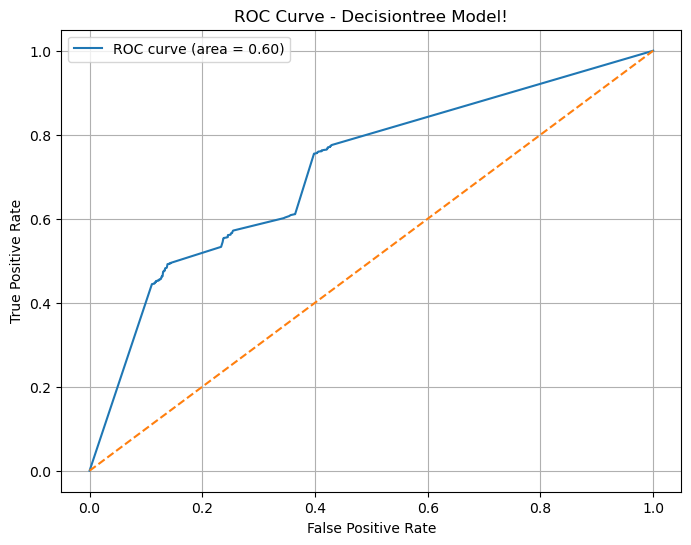

In [156]:
dtree_classification.plot_roc()

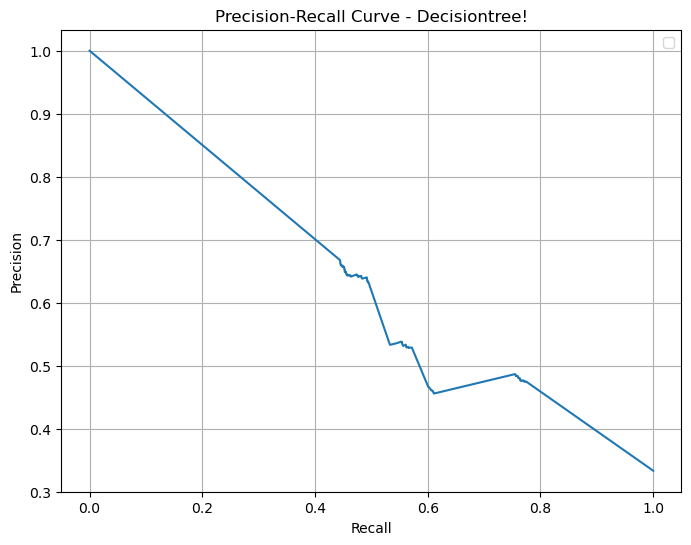

In [157]:
dtree_classification.plot_precision_recall()

In [158]:
rdm_forest_classification=Classification_Models(model_name='randomforest')
rdm_forest_class_scores=rdm_forest_classification.train_model_and_evalute()

========== Randomforest Model Initialization! ==========
======== PIPELINE FOR SPECIFIED MODEL: ========
Pipeline(steps=[('pca', PCA(n_components=0.95)),
                ('model', RandomForestClassifier(class_weight='balanced'))])
Randomforest Results:
Accuracy: 0.5636998254799301
Precision: 0.64715564199147
Recall: 0.5636998254799301
F1: 0.5922384825562329

===== Classification Report =====

              precision    recall  f1-score   support

         bad       0.22      0.48      0.30       531
       great       0.27      0.23      0.25       544
       so-so       0.79      0.64      0.71      2936

    accuracy                           0.56      4011
   macro avg       0.43      0.45      0.42      4011
weighted avg       0.65      0.56      0.59      4011



In [159]:
lightgbm_class=Classification_Models(model_name='lightgbm')
lightgbm_class_scores=lightgbm_class.train_model_and_evalute()

========== Lightgbm Model Initialization! ==========
======== PIPELINE FOR SPECIFIED MODEL: ========
Pipeline(steps=[('pca', PCA(n_components=0.95)), ('model', LGBMClassifier())])
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 16041, number of used features: 1
[LightGBM] [Info] Start training from score -2.021376
[LightGBM] [Info] Start training from score -1.998119
[LightGBM] [Info] Start training from score -0.312061
Lightgbm Results:
Accuracy: 0.7319870356519571
Precision: 0.5358050203625395
Recall: 0.7319870356519571
F1: 0.6187171258598377

===== Classification Report =====

              precision    recall  f1-score   support

         bad       0.00      0.00      0.00       531
       great       0.00      0.00      0.00       544
       so-so       0.73      1.00      0.85  

In [161]:
import sys, os

sys.path.insert(0, os.path.abspath('..'))
from joblib import dump

model = rdm_forest_classification
dump(model.pipe, '../data/model.pkl')

['../data/model.pkl']